# Sklearn Pipeline

In [1]:
# A Pipeline in Scikit-learn is a way to combine multiple steps (preprocessing + model) into one single

In [2]:
# Pipeline = Step-by-step process combined into one object

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
data = {
    'age': [22, 25, 30, 28, 35, 40, 23, 31, 29, 27],
    'city': ['Delhi', 'Mumbai', 'Delhi', 'Chennai', 'Mumbai', 'Delhi', 'Chennai', 'Mumbai', 'Delhi', 'Chennai'],
    'gender': ['Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female'],
    'cough': ['Mild', 'Strong', 'Mild', 'Strong', 'Mild', 'Strong', 'Mild', 'Strong', 'Mild', 'Strong'],
    'has_covid': [1,0,1,0,0,1,0,1,0,1]
}

df = pd.DataFrame(data)

In [7]:
df

,age,city,gender,cough,has_covid
0,22,Delhi,Male,Mild,1
1,25,Mumbai,Female,Strong,0
2,30,Delhi,Male,Mild,1
3,28,Chennai,Female,Strong,0
4,35,Mumbai,Male,Mild,0
5,40,Delhi,Female,Strong,1
6,23,Chennai,Male,Mild,0
7,31,Mumbai,Female,Strong,1
8,29,Delhi,Male,Mild,0
9,27,Chennai,Female,Strong,1


In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X = df.drop(columns=['has_covid'])

In [10]:
X

,age,city,gender,cough
0,22,Delhi,Male,Mild
1,25,Mumbai,Female,Strong
2,30,Delhi,Male,Mild
3,28,Chennai,Female,Strong
4,35,Mumbai,Male,Mild
5,40,Delhi,Female,Strong
6,23,Chennai,Male,Mild
7,31,Mumbai,Female,Strong
8,29,Delhi,Male,Mild
9,27,Chennai,Female,Strong


In [11]:
y = df['has_covid']

In [12]:
y

0    1
1    0
2    1
3    0
4    0
5    1
6    0
7    1
8    0
9    1
Name: has_covid, dtype: int64

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

In [17]:
X_train

,age,city,gender,cough
3,28,Chennai,Female,Strong
2,30,Delhi,Male,Mild
1,25,Mumbai,Female,Strong
6,23,Chennai,Male,Mild
4,35,Mumbai,Male,Mild
8,29,Delhi,Male,Mild
7,31,Mumbai,Female,Strong
9,27,Chennai,Female,Strong


In [18]:
X_test

,age,city,gender,cough
5,40,Delhi,Female,Strong
0,22,Delhi,Male,Mild


# WITHOUT PIPELINE

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder

In [24]:
transformer = ColumnTransformer(transformers=[
   ('ord', OrdinalEncoder(categories=[['Mild','Strong']]), ['cough']),
   ('ohe', OneHotEncoder(drop='first', sparse_output=False), ['city','gender'])
], remainder='passthrough')

In [25]:
transfer

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ord', ...), ('ohe', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``.

In [26]:
X_train_transformed = transformer.fit_transform(X_train)
X_test_transformed = transformer.transform(X_test)

In [27]:
X_train_transformed

array([[ 1.,  0.,  0.,  0., 28.],
       [ 0.,  1.,  0.,  1., 30.],
       [ 1.,  0.,  1.,  0., 25.],
       [ 0.,  0.,  0.,  1., 23.],
       [ 0.,  0.,  1.,  1., 35.],
       [ 0.,  1.,  0.,  1., 29.],
       [ 1.,  0.,  1.,  0., 31.],
       [ 1.,  0.,  0.,  0., 27.]])

In [28]:
X_test_transformed

array([[ 1.,  1.,  0.,  0., 40.],
       [ 0.,  1.,  0.,  1., 22.]])

# Train Model

In [29]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_transformed, y_train)

y_pred = model.predict(X_test_transformed)

In [30]:
y_pred

array([1, 0])

# Problems WITHOUT Pipeline

| Problem           | Explanation                               |
| ----------------- | ----------------------------------------- |
| Manual steps      | You must remember transform every time    |
| Easy to forget    | If you skip `transform(X_test)` → error   |
| Data leakage risk | If you use `fit_transform` on test data ❌ |
| Not reusable      | Hard to deploy                            |
| Code messy        | Multiple steps everywhere                 |


# WITH PIPELINE

In [31]:
from sklearn.pipeline import Pipeline

pipe = Pipeline(steps=[
    ('transform', transformer),
    ('model', LogisticRegression())
])

In [32]:
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('transform', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ord', ...), ('ohe', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [33]:
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

# WITH Pipeline

| Benefit         | Explanation                         |
| --------------- | ----------------------------------- |
| Automatic flow  | Transform + model together          |
| No forgetting   | Test data automatically transformed |
| No data leakage | Correct fitting internally          |
| Clean code      | Short and readable                  |
| Easy reuse      | Can save and deploy                 |


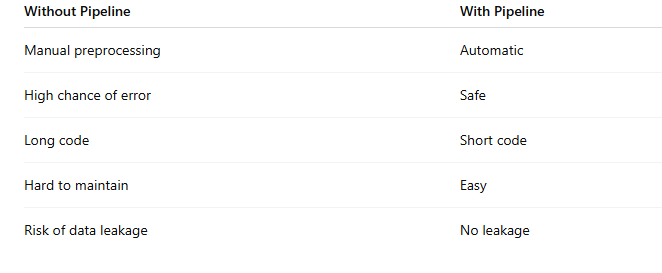

In [34]:
# Without Pipeline

#     Data → Transform → Model → Predict
#     (you control everything manually)

# With Pipeline
#     Data → Pipeline → Result
#     (everything automatic)

In [35]:
# Without pipeline, preprocessing and model training are handled separately, which can lead to errors and data leakage.
# With pipeline, all steps are combined, ensuring consistent and safe execution

In [36]:
data = {
    'age': [22, 25, 30, 28, 35, 40, 23, 31, 29, 27],
    'salary': [20000, 25000, 30000, 28000, 35000, 40000, 22000, 31000, 29000, 27000],
    'city': ['Delhi', 'Mumbai', 'Delhi', 'Chennai', 'Mumbai', 'Delhi', 'Chennai', 'Mumbai', 'Delhi', 'Chennai'],
    'gender': ['Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female'],
    'cough': ['Mild', 'Strong', 'Mild', 'Strong', 'Mild', 'Strong', 'Mild', 'Strong', 'Mild', 'Strong'],
    'has_covid': [1,0,1,0,0,1,0,1,0,1]
}

df = pd.DataFrame(data)

In [37]:
df

,age,salary,city,gender,cough,has_covid
0,22,20000,Delhi,Male,Mild,1
1,25,25000,Mumbai,Female,Strong,0
2,30,30000,Delhi,Male,Mild,1
3,28,28000,Chennai,Female,Strong,0
4,35,35000,Mumbai,Male,Mild,0
5,40,40000,Delhi,Female,Strong,1
6,23,22000,Chennai,Male,Mild,0
7,31,31000,Mumbai,Female,Strong,1
8,29,29000,Delhi,Male,Mild,0
9,27,27000,Chennai,Female,Strong,1


# Split Data

In [38]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['has_covid'])
y = df['has_covid']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [39]:
X_train

,age,salary,city,gender,cough
2,30,30000,Delhi,Male,Mild
6,23,22000,Chennai,Male,Mild
8,29,29000,Delhi,Male,Mild
9,27,27000,Chennai,Female,Strong
5,40,40000,Delhi,Female,Strong
0,22,20000,Delhi,Male,Mild
1,25,25000,Mumbai,Female,Strong
7,31,31000,Mumbai,Female,Strong


In [40]:
X_test

,age,salary,city,gender,cough
3,28,28000,Chennai,Female,Strong
4,35,35000,Mumbai,Male,Mild


# WITHOUT PIPELINE

In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

transformer = ColumnTransformer(transformers=[
    ('ord', OrdinalEncoder(categories=[['Mild','Strong']]), ['cough']),
    ('ohe', OneHotEncoder(drop='first', sparse_output=False), ['city','gender'])
], remainder='passthrough')

In [42]:
transformer

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ord', ...), ('ohe', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``.

In [43]:
# Manual Work

In [44]:
# train data
X_train_transformed = transformer.fit_transform(X_train)

# test data
X_test_transformed = transformer.transform(X_test)

In [45]:
X_train_transformed

array([[0.0e+00, 1.0e+00, 0.0e+00, 1.0e+00, 3.0e+01, 3.0e+04],
       [0.0e+00, 0.0e+00, 0.0e+00, 1.0e+00, 2.3e+01, 2.2e+04],
       [0.0e+00, 1.0e+00, 0.0e+00, 1.0e+00, 2.9e+01, 2.9e+04],
       [1.0e+00, 0.0e+00, 0.0e+00, 0.0e+00, 2.7e+01, 2.7e+04],
       [1.0e+00, 1.0e+00, 0.0e+00, 0.0e+00, 4.0e+01, 4.0e+04],
       [0.0e+00, 1.0e+00, 0.0e+00, 1.0e+00, 2.2e+01, 2.0e+04],
       [1.0e+00, 0.0e+00, 1.0e+00, 0.0e+00, 2.5e+01, 2.5e+04],
       [1.0e+00, 0.0e+00, 1.0e+00, 0.0e+00, 3.1e+01, 3.1e+04]])

In [46]:
X_test_transformed

array([[1.0e+00, 0.0e+00, 0.0e+00, 0.0e+00, 2.8e+01, 2.8e+04],
       [0.0e+00, 0.0e+00, 1.0e+00, 1.0e+00, 3.5e+01, 3.5e+04]])

# Train Model

In [47]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_transformed, y_train)

y_pred = model.predict(X_test_transformed)

C:\Users\u\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [48]:
# PROBLEMS WITHOUT PIPELINE

In [49]:
# Forgetting Step (Very Common)

#     If you do this mistake:

# model.predict(X_test)   # ❌ WRONG

#   Error will come because:

# Model expects transformed data


#         But you gave raw data
#             Data Leakage (VERY IMPORTANT)

#   If you do:
        
#         transformer.fit_transform(X_test)   # ❌ WRONG

# Problem:
            
#                 Model learns from test data
#                 Accuracy becomes fake

# 3. Inconsistent Processing

#          Train and test may get different processing
#          Leads to wrong predictions

# 4. Code is Messy
#         Too many steps
#         Hard to maintain
#         Easy to make mistakes

# WITH PIPELINE

In [50]:
from sklearn.pipeline import Pipeline

pipe = Pipeline(steps=[
    ('transform', transformer),
    ('model', LogisticRegression())
])

In [51]:
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('transform', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ord', ...), ('ohe', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [52]:
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

C:\Users\u\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [53]:
# WHAT PIPELINE DOES INTERNALLY

In [54]:
# Step 1: Fit transformer on X_train
# Step 2: Transform X_train
# Step 3: Train model
# Step 4: Transform X_test (automatically)
# Step 5: Predict